Устройство: cpu
Python: C:\Users\Alexe\AppData\Local\Programs\Python\Python313\python.exe
Версия: 3.13.3
PyTorch: 2.11.0+cpu
Строк: 164860
Пропуски energy/power (всего): 0
Дубликаты dt: 0
Даты: от 2018-01-01 00:00:00+00:00 до 2022-09-22 13:45:00+00:00
              energy          power
count  164860.000000  164860.000000
mean      193.032770     772.131078
std        53.349186     213.396744
min       105.200000     420.800000
25%       151.200000     604.800000
50%       179.200000     716.800000
75%       222.800000     891.200000
max       461.200000    1844.800000


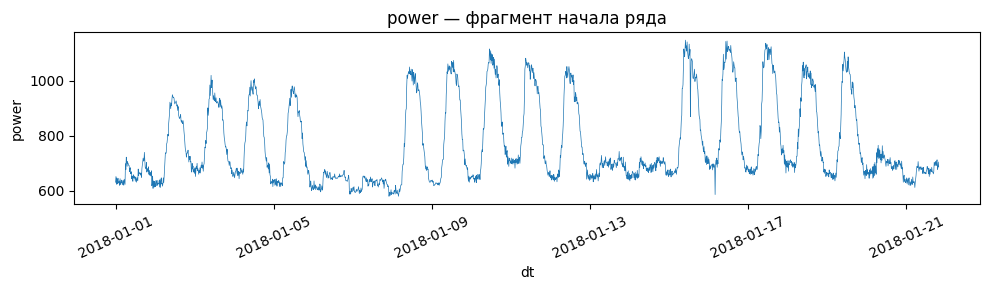

In [1]:
'''
БЛОК 1. ОКРУЖЕНИЕ, ПУТЬ К ФАЙЛУ, SEED, ПЕРВИЧНЫЙ ОСМОТР РЯДА (ЛР №3, вариант 8)

Зачем этот блок:
- Зафиксировать устройство (CPU/GPU) и версию Python для отчёта.
- Задать единый SEED для random / NumPy / torch (воспроизводимость окон и обучения RNN/LSTM/GRU).
- Указать путь к timeseries_energy_power.csv (файл лежит в той же папке, что и ноутбук).
- Загрузить данные, распарсить время, отсортировать по времени, проверить пропуски и дубликаты по dt.
- Вывести размер, диапазон дат, describe по числовым колонкам и построить короткий график power — для раздела «Выбранный датасет».

Дальше по лабе: блок 2 — разбиение train/val/test только по времени, MinMaxScaler на train, класс Dataset со скользящим окном, DataLoader.
'''

import os  # Переменные окружения и работа с путями ОС
import random  # Фиксация seed для модуля random
import sys  # Вывод пути к интерпретатору Python для отчёта
from pathlib import Path  # Удобные пути к CSV относительно ноутбука

import matplotlib.pyplot as plt  # График фрагмента ряда для отчёта
import numpy as np  # Численные операции и общий seed с torch
import pandas as pd  # Загрузка и анализ таблицы временного ряда
import torch  # Дальше все нейросети; здесь — device и seed

os.environ.setdefault("TMP", r"D:\tmp")  # Временные файлы на D:, если не задано
os.environ.setdefault("TEMP", r"D:\tmp")  # То же для TEMP (некоторые библиотеки читают оба)
Path(os.environ["TMP"]).mkdir(parents=True, exist_ok=True)  # Создать каталог tmp, чтобы не падать на записи

SEED = 42  # Единое значение воспроизводимости для всего ноутбука
random.seed(SEED)  # Фиксируем случайность стандартной библиотеки
np.random.seed(SEED)  # Фиксируем случайность NumPy (индексы, если появятся)
torch.manual_seed(SEED)  # Фиксируем случайность PyTorch на CPU
if torch.cuda.is_available():  # Если есть GPU
    torch.cuda.manual_seed_all(SEED)  # Фиксируем seed и на всех устройствах CUDA

torch.backends.cudnn.deterministic = True  # Более предсказуемые алгоритмы cuDNN
torch.backends.cudnn.benchmark = False  # Не подбирать эвристики ради строгой воспроизводимости

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Куда положим модели в следующих блоках
print("Устройство:", device)  # Печать для отчёта: CPU или CUDA
print("Python:", sys.executable)  # Проверка, что ядро — из нужного venv
print("Версия:", sys.version.split()[0])  # Кратко версия Python
print("PyTorch:", torch.__version__)  # Версия PyTorch для воспроизводимости

DATA_PATH = Path.cwd() / "timeseries_energy_power.csv"  # CSV в той же папке, что и ноутбук
assert DATA_PATH.exists(), f"Не найден файл: {DATA_PATH.resolve()}"  # Явная ошибка, если файл не там

df = pd.read_csv(DATA_PATH)  # Чтение таблицы с рядом energy/power
df["dt"] = pd.to_datetime(df["dt"], utc=True)  # Парсинг меток времени в едином UTC
df = df.sort_values("dt").reset_index(drop=True)  # Хронологический порядок обязателен для рядов

n_nan = df[["energy", "power"]].isna().sum().sum()  # Сколько пропусков в целевых колонках
dup_dt = df["dt"].duplicated().sum()  # Дубликаты времени ломают однозначность ряда
print("Строк:", len(df))  # Размер датасета для отчёта
print("Пропуски energy/power (всего):", int(n_nan))  # Контроль качества данных
print("Дубликаты dt:", int(dup_dt))  # Должно быть 0 или объяснено в отчёте
print("Даты: от", df["dt"].min(), "до", df["dt"].max())  # Охват периода наблюдений
print(df[["energy", "power"]].describe())  # Минимум/максимум/квартили для раздела «Датасет»

fig, ax = plt.subplots(figsize=(10, 3))  # Широкая фигура для временной оси
n = min(2000, len(df))  # Не перегружать график: первые 2000 точек или меньше
ax.plot(df["dt"].iloc[:n], df["power"].iloc[:n], lw=0.5)  # Линия мощности по времени
ax.set_title("power — фрагмент начала ряда")  # Подпись для вставки в отчёт
ax.set_xlabel("dt")  # Ось X — время
ax.set_ylabel("power")  # Ось Y — целевой ряд (можно позже предсказывать его)
plt.xticks(rotation=25)  # Подписи дат читаемее
plt.tight_layout()  # Поджать поля вокруг графика
plt.show()  # Показать в ноутбуке

In [2]:
'''
БЛОК 2. РАЗБИЕНИЕ ПО ВРЕМЕНИ, MinMaxScaler, ОКНА, DataLoader (ЛР №3)

Зачем:
- Train/val/test только по хронологии (без shuffle), как в методичке по рядам.
- Обучить MinMaxScaler только на train — без утечки статистик val/test.
- Сформировать окна длины SEQ_LEN: вход — прошлые шаги, цель — следующий шаг по power.
- Обернуть в torch.utils.data.Dataset и DataLoader для батчевого обучения RNN/LSTM/GRU.

Дальше: блок 3 — классы моделей VanillaRNN / LSTM / GRU с одинаковым head и цикл обучения.
'''

import numpy as np  # Массивы после масштабирования
import pandas as pd  # На случай доработки таблицы
import torch  # Тензоры для Dataset
from sklearn.preprocessing import MinMaxScaler  # Масштабирование признаков
from torch.utils.data import DataLoader, Dataset  # Батчи для обучения

SEQ_LEN = 96  # Длина окна: 96×15 мин = 24 часа (одни сутки контекста)
BATCH_SIZE = 64  # Размер батча; при нехватке памяти уменьшить
TARGET_COL = "power"  # Прогнозируем мощность (можно сменить на energy)

assert "df" in globals(), "Сначала выполните блок 1 и получите df"  # Защита от порядка ячеек
n = len(df)  # Число точек ряда после сортировки по времени
i_train = int(0.70 * n)  # Граница train (70% с начала)
i_val = int(0.85 * n)  # Граница val (следующие 15%)
train_df = df.iloc[:i_train].copy()  # Обучающий отрезок по времени
val_df = df.iloc[i_train:i_val].copy()  # Валидационный отрезок
test_df = df.iloc[i_val:].copy()  # Тестовый отрезок (последние 15%)
print("train / val / test:", len(train_df), len(val_df), len(test_df))  # Контроль размеров для отчёта

scaler = MinMaxScaler()  # Приведение power к [0, 1] на train
scaler.fit(train_df[[TARGET_COL]])  # fit только на train — без утечки
train_scaled = scaler.transform(train_df[[TARGET_COL]])  # (N_train, 1)
val_scaled = scaler.transform(val_df[[TARGET_COL]])  # Те же параметры scaler
test_scaled = scaler.transform(test_df[[TARGET_COL]])  # Те же параметры scaler


class WindowDataset(Dataset):  # PyTorch Dataset: окно → следующая точка
    def __init__(self, data_2d, seq_len):  # data_2d: массив формы (N, 1)
        self.data = data_2d.astype(np.float32)  # float32 достаточно для сети
        self.seq_len = int(seq_len)  # Длина входной последовательности
        if len(self.data) <= self.seq_len:  # Нужно хотя бы seq_len+1 точка
            raise ValueError("Слишком мало точек для выбранного SEQ_LEN")  # Явная ошибка

    def __len__(self):  # Число обучающих примеров
        return len(self.data) - self.seq_len  # Последнее окно заканчивается на предпоследней точке

    def __getitem__(self, idx):  # Один пример по индексу
        x = self.data[idx : idx + self.seq_len]  # Окно (seq_len, 1)
        y = self.data[idx + self.seq_len]  # Следующий шаг (1,)
        return torch.from_numpy(x), torch.from_numpy(y)  # Тензоры для DataLoader


train_ds = WindowDataset(train_scaled, SEQ_LEN)  # Датасет обучения
val_ds = WindowDataset(val_scaled, SEQ_LEN)  # Датасет валидации
test_ds = WindowDataset(test_scaled, SEQ_LEN)  # Датасет теста

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)  # shuffle=True только внутри train (окна не перемешивают порядок времени в исходном ряду — это перемешивание батчей, не времени)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)  # Val без shuffle
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)  # Test без shuffle

xb, yb = next(iter(train_loader))  # Проверка одного батча
print("X batch:", xb.shape, " y batch:", yb.shape)  # Ожидается (B, SEQ_LEN, 1) и (B, 1)
print("device:", device)  # Напоминание: в модели перенесёте на device

train / val / test: 115401 24730 24729
X batch: torch.Size([64, 96, 1])  y batch: torch.Size([64, 1])
device: cpu


In [3]:
'''
БЛОК 3. МОДЕЛИ RNN / LSTM / GRU, ОБУЧЕНИЕ, МЕТРИКИ MSE / MAE / R² (ЛР №3)

Соответствие методичке:
- Три разных рекуррентных блока: nn.RNN, nn.LSTM, nn.GRU на одном и том же пайплайне данных.
- Сравнение качества по метрикам MSE, MAE, R² (задача регрессии ряда).
- Одинаковые размерности входа (batch, SEQ_LEN, 1), общий линейный выход на 1 шаг вперёд.

Зачем:
- Реализовать честное сравнение: одни и те же HIDDEN_SIZE, NUM_LAYERS, LR, EPOCHS, early stopping.
- Получить таблицу метрик на test и графики loss для отчёта (разделы «Модели», «Обучение», «Сравнение»).

Дальше: блок 4 — визуализация предсказаний на фрагменте test и финальная сводная таблица для выводов.
'''

import copy  # Копия состояния лучшей модели по val loss
import numpy as np  # Сбор предсказаний на всём test
import torch  # Обучение и инференс
import torch.nn as nn  # Рекуррентные слои и полносвязный выход
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Метрики из задания

assert "train_loader" in globals() and "scaler" in globals() and "device" in globals()  # Зависимость от блоков 1–2
assert "TARGET_COL" in globals()  # Имя целевого столбца для подписей

INPUT_SIZE = 1  # Один канал — масштабированный power
HIDDEN_SIZE = 64  # Размер скрытого слоя (одинаковый для трёх моделей)
NUM_LAYERS = 1  # Число слоёв RNN/LSTM/GRU (одинаковое)
DROPOUT_P = 0.1  # Одинаковая регуляризация после последнего по времени выхода
LR = 1e-3  # Скорость обучения Adam
EPOCHS = 50  # Максимум эпох (с ранней остановкой)
PATIENCE = 7  # Эпох без улучшения val loss до остановки


class RNNRegressor(nn.Module):  # «Ванильная» RNN + голова регрессии
    def __init__(self, input_size, hidden_size, num_layers, dropout_p):  # Параметры сети
        super().__init__()  # Инициализация базового класса
        self.rnn = nn.RNN(  # Рекуррентный слой из методички (базовая RNN)
            input_size,  # Размер входа на шаг (1)
            hidden_size,  # Размер скрытого состояния
            num_layers,  # Число слоёв стека RNN
            batch_first=True,  # Форма (batch, seq, feat)
            nonlinearity="tanh",  # Тип нелинейности внутри RNN
        )  # Конец nn.RNN
        self.dropout = nn.Dropout(dropout_p)  # Снижение переобучения перед выходом
        self.fc = nn.Linear(hidden_size, 1)  # Прогноз следующего значения power (масштаб)

    def forward(self, x):  # x: (batch, seq, 1)
        out, _ = self.rnn(x)  # out: (batch, seq, hidden)
        last = out[:, -1, :]  # Берём представление последнего шага окна
        last = self.dropout(last)  # Dropout на векторе последнего шага
        return self.fc(last)  # (batch, 1) — прогноз в масштабе scaler


class LSTMRegressor(nn.Module):  # LSTM + та же голова (требование: отдельная архитектура LSTM)
    def __init__(self, input_size, hidden_size, num_layers, dropout_p):  # Те же сигнатуры
        super().__init__()  # Базовый конструктор
        self.lstm = nn.LSTM(  # Долгая память (из теории ЛР3)
            input_size,  # 1
            hidden_size,  # 64
            num_layers,  # 1
            batch_first=True,  # (batch, seq, feat)
        )  # Конец LSTM
        self.dropout = nn.Dropout(dropout_p)  # Тот же dropout, что и у RNN
        self.fc = nn.Linear(hidden_size, 1)  # Линейный выход

    def forward(self, x):  # Прямой проход
        out, _ = self.lstm(x)  # out: (batch, seq, hidden)
        last = out[:, -1, :]  # Последний момент окна
        last = self.dropout(last)  # Dropout
        return self.fc(last)  # Прогноз


class GRURegressor(nn.Module):  # GRU + та же голова (третья модель по заданию)
    def __init__(self, input_size, hidden_size, num_layers, dropout_p):  # Единый интерфейс
        super().__init__()  # Базовый класс
        self.gru = nn.GRU(  # GRU-рекуррентный блок
            input_size,  # 1
            hidden_size,  # 64
            num_layers,  # 1
            batch_first=True,  # Форма батча
        )  # Конец GRU
        self.dropout = nn.Dropout(dropout_p)  # Аналогично двум другим сетям
        self.fc = nn.Linear(hidden_size, 1)  # Выход регрессии

    def forward(self, x):  # x (batch, seq, 1)
        out, _ = self.gru(x)  # Последовательность скрытых состояний
        last = out[:, -1, :]  # Последний шаг
        last = self.dropout(last)  # Регуляризация
        return self.fc(last)  # Предсказание


def train_one_epoch(model, loader, criterion, optimizer, dev):  # Один проход по train
    model.train()  # Режим обучения (dropout активен)
    total_loss = 0.0  # Накопление MSE по батчам
    n_batches = 0  # Счётчик батчей
    for xb, yb in loader:  # Батчи из WindowDataset
        xb = xb.to(dev)  # На CPU или CUDA
        yb = yb.to(dev)  # Целевой следующий шаг
        optimizer.zero_grad()  # Обнуление градиентов
        pred = model(xb)  # (batch, 1)
        loss = criterion(pred, yb)  # MSE в масштабе scaler
        loss.backward()  # Обратное распространение
        optimizer.step()  # Шаг оптимизатора
        total_loss += loss.item() * xb.size(0)  # Вклад батча в суммарную ошибку
        n_batches += xb.size(0)  # Число примеров
    return total_loss / max(n_batches, 1)  # Средний MSE на train за эпоху


@torch.no_grad()  # Без градиентов на валидации/тесте
def eval_loss(model, loader, criterion, dev):  # Средний MSE на выборке
    model.eval()  # Режим инференса
    total_loss = 0.0  # Сумма ошибок
    n = 0  # Число точек
    for xb, yb in loader:  # Батчи
        xb = xb.to(dev)  # Устройство
        yb = yb.to(dev)  # Цель
        pred = model(xb)  # Предсказание
        loss = criterion(pred, yb)  # MSE по батчу
        total_loss += loss.item() * xb.size(0)  # Накопление
        n += xb.size(0)  # Счётчик примеров
    return total_loss / max(n, 1)  # Средний MSE


@torch.no_grad()  # Инференс на всём loader
def predict_all(model, loader, dev):  # Собрать все y и pred (масштаб scaler)
    model.eval()  # eval
    ys = []  # Список истинных значений
    ps = []  # Список предсказаний
    for xb, yb in loader:  # По батчам
        xb = xb.to(dev)  # Вход
        pred = model(xb)  # (batch,1)
        ys.append(yb.numpy())  # В CPU numpy
        ps.append(pred.cpu().numpy())  # Предсказания на CPU
    y_all = np.vstack(ys)  # (N,1)
    p_all = np.vstack(ps)  # (N,1)
    return y_all, p_all  # Для метрик и обратного масштаба


def metrics_original_scale(y_scaled, p_scaled, sc, col_name):  # MSE, MAE, R² в исходных единицах power
    y_orig = sc.inverse_transform(y_scaled)  # Истина в кВт·усл. (как в CSV)
    p_orig = sc.inverse_transform(p_scaled)  # Предсказание в тех же единицах
    mse = mean_squared_error(y_orig, p_orig)  # MSE по заданию
    mae = mean_absolute_error(y_orig, p_orig)  # MAE по заданию
    r2 = r2_score(y_orig, p_orig)  # R² по заданию
    return {"MSE": mse, "MAE": mae, "R2": r2}  # Словарь для таблицы отчёта


def run_training(name, model_class, dev):  # Универсальный цикл для одной архитектуры
    torch.manual_seed(SEED)  # Воспроизводимость весов инициализации
    if torch.cuda.is_available():  # Если CUDA
        torch.cuda.manual_seed_all(SEED)  # Seed на GPU
    model = model_class(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT_P).to(dev)  # Экземпляр модели на device
    criterion = nn.MSELoss()  # Согласовано с метрикой MSE из методички
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)  # Оптимизатор Adam (как в примерах ЛР2/3)
    best_state = None  # Лучшие веса по val
    best_val = float("inf")  # Минимальный val MSE
    patience_left = PATIENCE  # Счётчик терпения early stopping
    history = {"train": [], "val": []}  # История для графиков в отчёт
    for epoch in range(1, EPOCHS + 1):  # Эпохи
        tr = train_one_epoch(model, train_loader, criterion, optimizer, dev)  # Train MSE
        va = eval_loss(model, val_loader, criterion, dev)  # Val MSE
        history["train"].append(tr)  # Лог train
        history["val"].append(va)  # Лог val
        if va < best_val - 1e-9:  # Улучшение на валидации
            best_val = va  # Обновить лучший val
            best_state = copy.deepcopy(model.state_dict())  # Сохранить веса
            patience_left = PATIENCE  # Сбросить patience
        else:  # Без улучшения
            patience_left -= 1  # Уменьшить счётчик
            if patience_left <= 0:  # Ранняя остановка
                break  # Выход из цикла эпох
    if best_state is not None:  # Если что-то сохранили
        model.load_state_dict(best_state)  # Загрузить лучшие веса по val
    y_test, p_test = predict_all(model, test_loader, dev)  # Предсказания на test
    m = metrics_original_scale(y_test, p_test, scaler, TARGET_COL)  # MSE, MAE, R² в оригинале
    return name, model, history, m  # Имя, модель, кривые, метрики


results = {}  # Словарь метрик по моделям
histories = {}  # Словарь кривых для графиков
models_out = {}  # Обученные модели (если нужны дальше)

name, model, history, m = run_training("RNN", RNNRegressor, device)  # Обучение vanilla RNN
results[name] = m  # Запись метрик
histories[name] = history  # История loss
models_out[name] = model  # Сохранить модель
print("RNN test (ориг. масштаб):", m)  # Печать для отчёта

name, model, history, m = run_training("LSTM", LSTMRegressor, device)  # Обучение LSTM
results[name] = m  # Метрики LSTM
histories[name] = history  # История
models_out[name] = model  # Модель
print("LSTM test (ориг. масштаб):", m)  # Печать

name, model, history, m = run_training("GRU", GRURegressor, device)  # Обучение GRU
results[name] = m  # Метрики GRU
histories[name] = history  # История
models_out[name] = model  # Модель
print("GRU test (ориг. масштаб):", m)  # Печать

import pandas as pd  # Таблица сравнения для отчёта

summary = pd.DataFrame(results).T  # Строки — модели, столбцы — MSE, MAE, R2
print("\nСводная таблица (test, исходные единицы power):")  # Заголовок
print(summary)  # Вывод таблицы

RNN test (ориг. масштаб): {'MSE': 1470.3536376953125, 'MAE': 20.598817825317383, 'R2': 0.9646313190460205}
LSTM test (ориг. масштаб): {'MSE': 1503.320556640625, 'MAE': 20.50358009338379, 'R2': 0.9638382792472839}
GRU test (ориг. масштаб): {'MSE': 1477.10498046875, 'MAE': 20.13258171081543, 'R2': 0.9644688963890076}

Сводная таблица (test, исходные единицы power):
              MSE        MAE        R2
RNN   1470.353638  20.598818  0.964631
LSTM  1503.320557  20.503580  0.963838
GRU   1477.104980  20.132582  0.964469


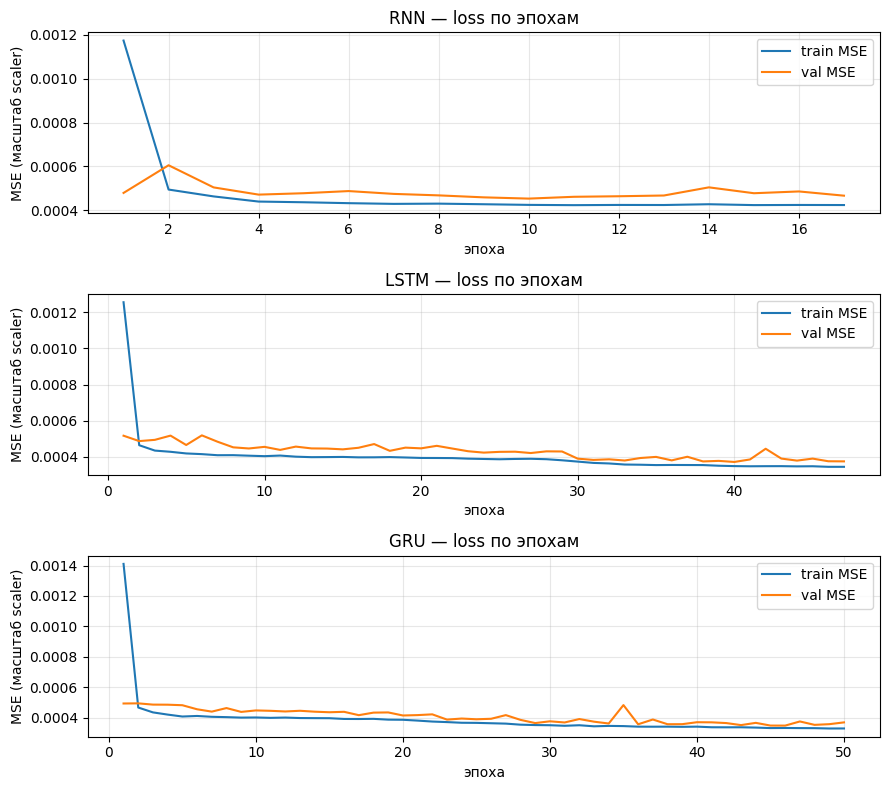

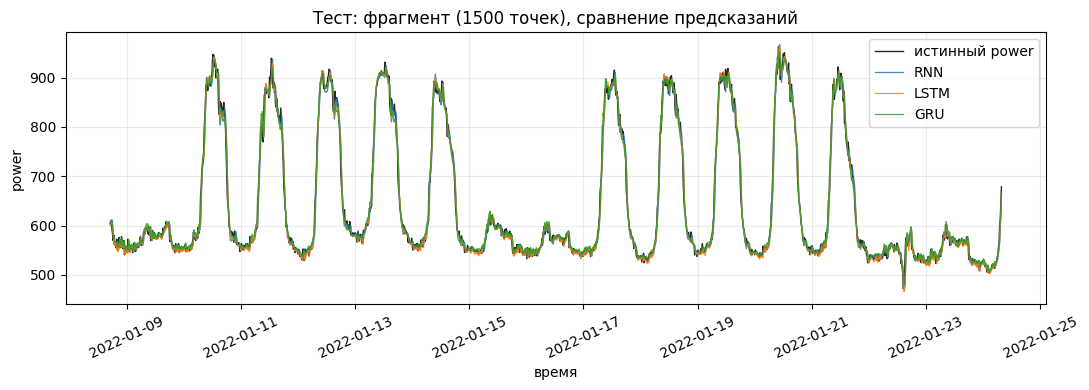

Готово: графики для разделов «Процесс обучения» и «Сравнение моделей».


In [4]:
'''
БЛОК 4. ВИЗУАЛИЗАЦИЯ ДЛЯ ОТЧЁТА (ЛР №3)

Зачем:
- Графики MSE по эпохам (train / val) для RNN, LSTM, GRU — раздел «Процесс обучения».
- Фрагмент тестового ряда: истинный power и предсказания (все три модели или только лучшая по MAE) — раздел «Сравнение моделей».

Дальше: оформление отчёта по структуре методички, приложение с ноутбуком или Colab.
'''

import matplotlib.pyplot as plt  # Графики для вставки в отчёт
import numpy as np  # Индексы для среза фрагмента

assert "histories" in globals() and "models_out" in globals()  # После блока 3
assert "test_loader" in globals() and "scaler" in globals() and "test_df" in globals()  # После блоков 2–3
assert "SEQ_LEN" in globals() and "device" in globals()  # Параметры окон и устройства
assert "predict_all" in globals()  # Функция из блока 3

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=False)  # Три строки — по одной модели
for ax, name in zip(axes, ["RNN", "LSTM", "GRU"]):  # Обход моделей
    h = histories[name]  # Словари train и val
    ep = range(1, len(h["train"]) + 1)  # Номера эпох с 1
    ax.plot(ep, h["train"], label="train MSE", lw=1.5)  # Кривая обучения
    ax.plot(ep, h["val"], label="val MSE", lw=1.5)  # Кривая валидации
    ax.set_title(f"{name} — loss по эпохам")  # Заголовок подписи
    ax.set_xlabel("эпоха")  # Ось X
    ax.set_ylabel("MSE (масштаб scaler)")  # Ось Y в масштабе MinMax
    ax.legend()  # Легенда
    ax.grid(True, alpha=0.3)  # Сетка
plt.tight_layout()  # Отступы
plt.show()  # Показать рисунок

y_true_s, p_rnn = predict_all(models_out["RNN"], test_loader, device)  # Предсказания RNN на test
_, p_lstm = predict_all(models_out["LSTM"], test_loader, device)  # Предсказания LSTM
_, p_gru = predict_all(models_out["GRU"], test_loader, device)  # Предсказания GRU

y_true = scaler.inverse_transform(y_true_s)  # Истинный power в исходных единицах
pred_rnn = scaler.inverse_transform(p_rnn)  # RNN в исходных единицах
pred_lstm = scaler.inverse_transform(p_lstm)  # LSTM
pred_gru = scaler.inverse_transform(p_gru)  # GRU

n_pred = len(y_true)  # Число точек на test
dt_index = slice(SEQ_LEN, SEQ_LEN + n_pred)  # Метки времени для целевых шагов окон
dts = test_df["dt"].iloc[dt_index].values  # Datetime под каждое предсказание

k = min(1500, n_pred)  # Длина фрагмента для читаемого графика
sl = slice(0, k)  # Срез начала теста

plt.figure(figsize=(11, 4))  # Широкий график
plt.plot(dts[sl], y_true[sl, 0], "k-", lw=1.0, label="истинный power", alpha=0.85)  # Факт
plt.plot(dts[sl], pred_rnn[sl, 0], "-", lw=0.9, label="RNN", alpha=0.85)  # RNN
plt.plot(dts[sl], pred_lstm[sl, 0], "-", lw=0.9, label="LSTM", alpha=0.85)  # LSTM
plt.plot(dts[sl], pred_gru[sl, 0], "-", lw=0.9, label="GRU", alpha=0.85)  # GRU
plt.xlabel("время")  # Ось X
plt.ylabel("power")  # Ось Y
plt.title(f"Тест: фрагмент ({k} точек), сравнение предсказаний")  # Заголовок
plt.legend()  # Легенда
plt.xticks(rotation=25)  # Поворот подписей дат
plt.grid(True, alpha=0.25)  # Сетка
plt.tight_layout()  # Поля
plt.show()  # Рисунок для отчёта

print("Готово: графики для разделов «Процесс обучения» и «Сравнение моделей».")  # Контроль в ноутбуке